In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("musinsa_pants.csv")
df

,상품명,판매가,정가,할인율,리뷰수
0,상반기 결산세일,37910,39905,5,411.0
1,우먼즈 코튼 카프리 팬츠 [블랙],37910,39905,5,411.0
2,[NEW 컬러 출시] 우먼즈 코튼 커브드 팬츠 (5 colors),39720,49650,20,NaN
3,우먼즈 와이드 카고 팬츠 [크림],33540,55900,40,NaN
4,우먼즈 커브드 치노 팬츠 [베이지],40420,49901,19,284.0
5,[쿨탠다드] 우먼즈 로 라이즈 플레어 슬랙스 [블랙],33050,45903,28,140.0
6,[쿨탠다드] 우먼즈 쿨링 딥 턱 와이드 밴딩 팬츠 [블랙],29850,43897,32,NaN
7,우먼즈 플루이드 로 웨이스트 와이드 슬랙스 [블랙],29940,49900,40,122.0
8,우먼즈 코튼 밴딩 쇼츠 [블랙],17940,29900,40,54.0
9,우먼즈 와이드 카고 팬츠 [블랙],33340,55567,40,NaN


In [2]:
# 데이터 기본 정보 확인
print("데이터 크기:", df.shape)
print()
df.info()

데이터 크기: (31, 5)

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   상품명     31 non-null     str    
 1   판매가     31 non-null     int64  
 2   정가      31 non-null     int64  
 3   할인율     31 non-null     int64  
 4   리뷰수     22 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 1.3 KB


In [3]:
# 리뷰수 결측치 확인
print("리뷰수 결측치 개수:", df["리뷰수"].isna().sum())

# 결측치 제외한 데이터로 기본 통계 확인
df_clean = df.dropna(subset=["리뷰수"])
print("\n분석 대상 상품 개수:", len(df_clean))
print()
df_clean[["판매가", "정가", "할인율", "리뷰수"]].describe()

리뷰수 결측치 개수: 9

분석 대상 상품 개수: 22



,판매가,정가,할인율,리뷰수
count,22.000000,22.000000,22.000000,22.000000
mean,34875.454545,45342.500000,22.818182,285.363636
std,7558.525762,8121.518904,12.557056,243.439157
min,17940.000000,25896.000000,5.000000,25.000000
25%,30487.500000,39905.000000,18.250000,101.750000
50%,37180.000000,45901.000000,20.000000,235.000000
75%,39417.500000,49900.000000,33.750000,411.000000
max,47410.000000,59900.000000,40.000000,910.000000


할인율과 리뷰수의 상관계수: -0.336


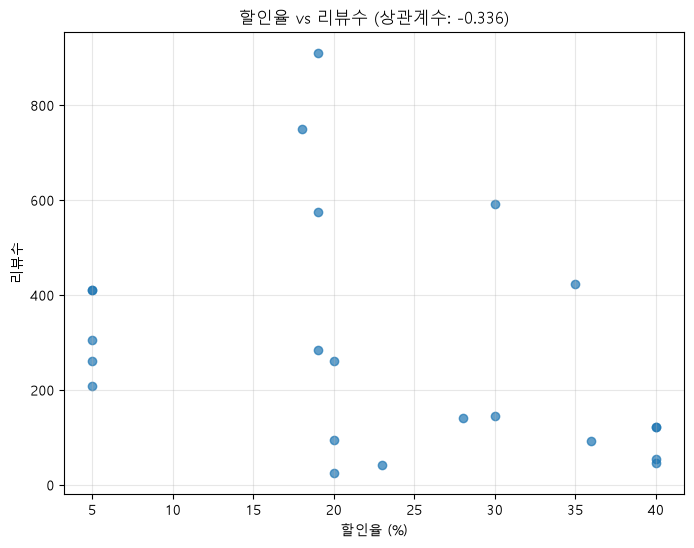

In [4]:
# 상관계수 계산
corr = df_clean["할인율"].corr(df_clean["리뷰수"])
print(f"할인율과 리뷰수의 상관계수: {corr:.3f}")

# 산점도 그리기
plt.figure(figsize=(8, 6))
plt.scatter(df_clean["할인율"], df_clean["리뷰수"], alpha=0.7)
plt.xlabel("할인율 (%)")
plt.ylabel("리뷰수")
plt.title(f"할인율 vs 리뷰수 (상관계수: {corr:.3f})")
plt.grid(True, alpha=0.3)
plt.show()